In [6]:
using Oceananigans
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("../src-fig/video/full_video.jl")

full_video (generic function with 1 method)

601 / 601 


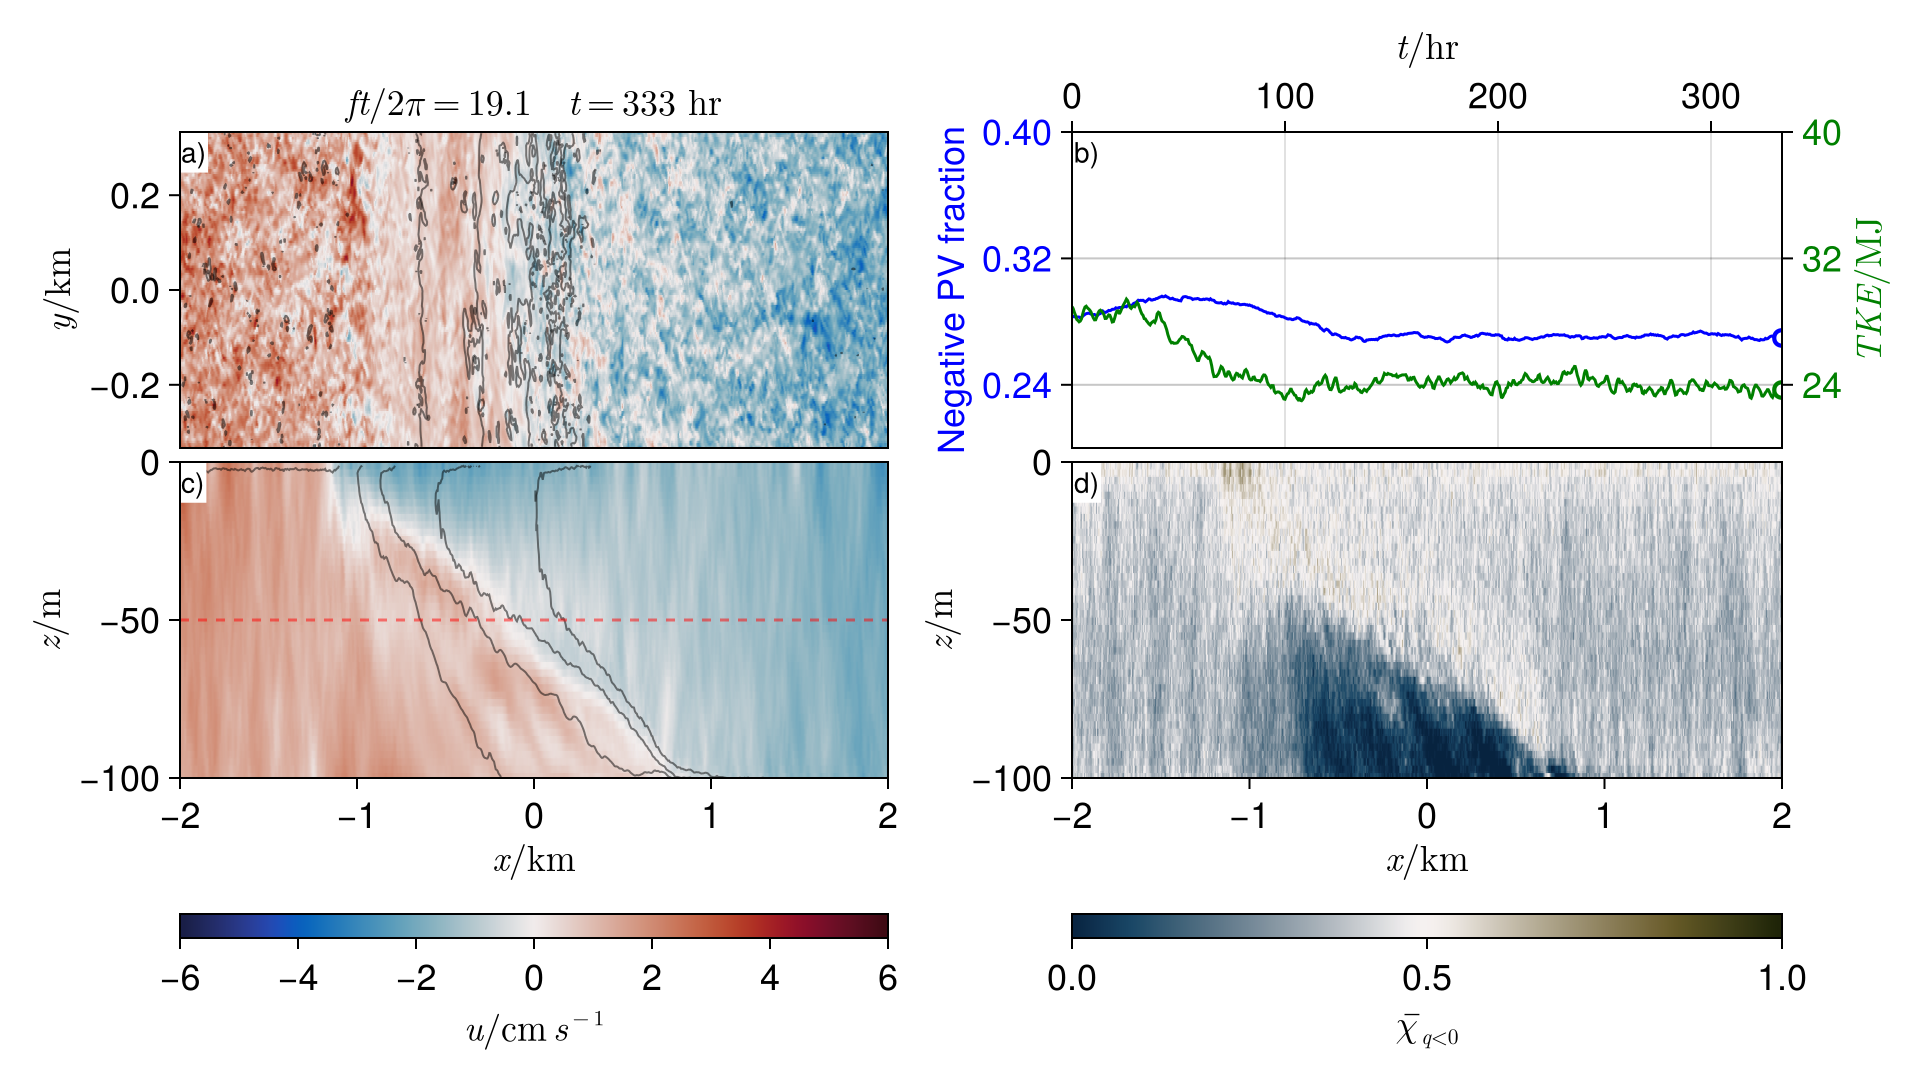

In [17]:
foldername = "../../scratch/turbulence-at-many-fronts/Strain-l2"
full_video(foldername, "full-l2.mp4", 201:801, -50; background=true, fig_kw=(; fontsize=18), record_kw=(; px_per_unit=2, framerate=12), ht_u_kw=(; highclip=nothing, lowclip=nothing))


601 / 601 


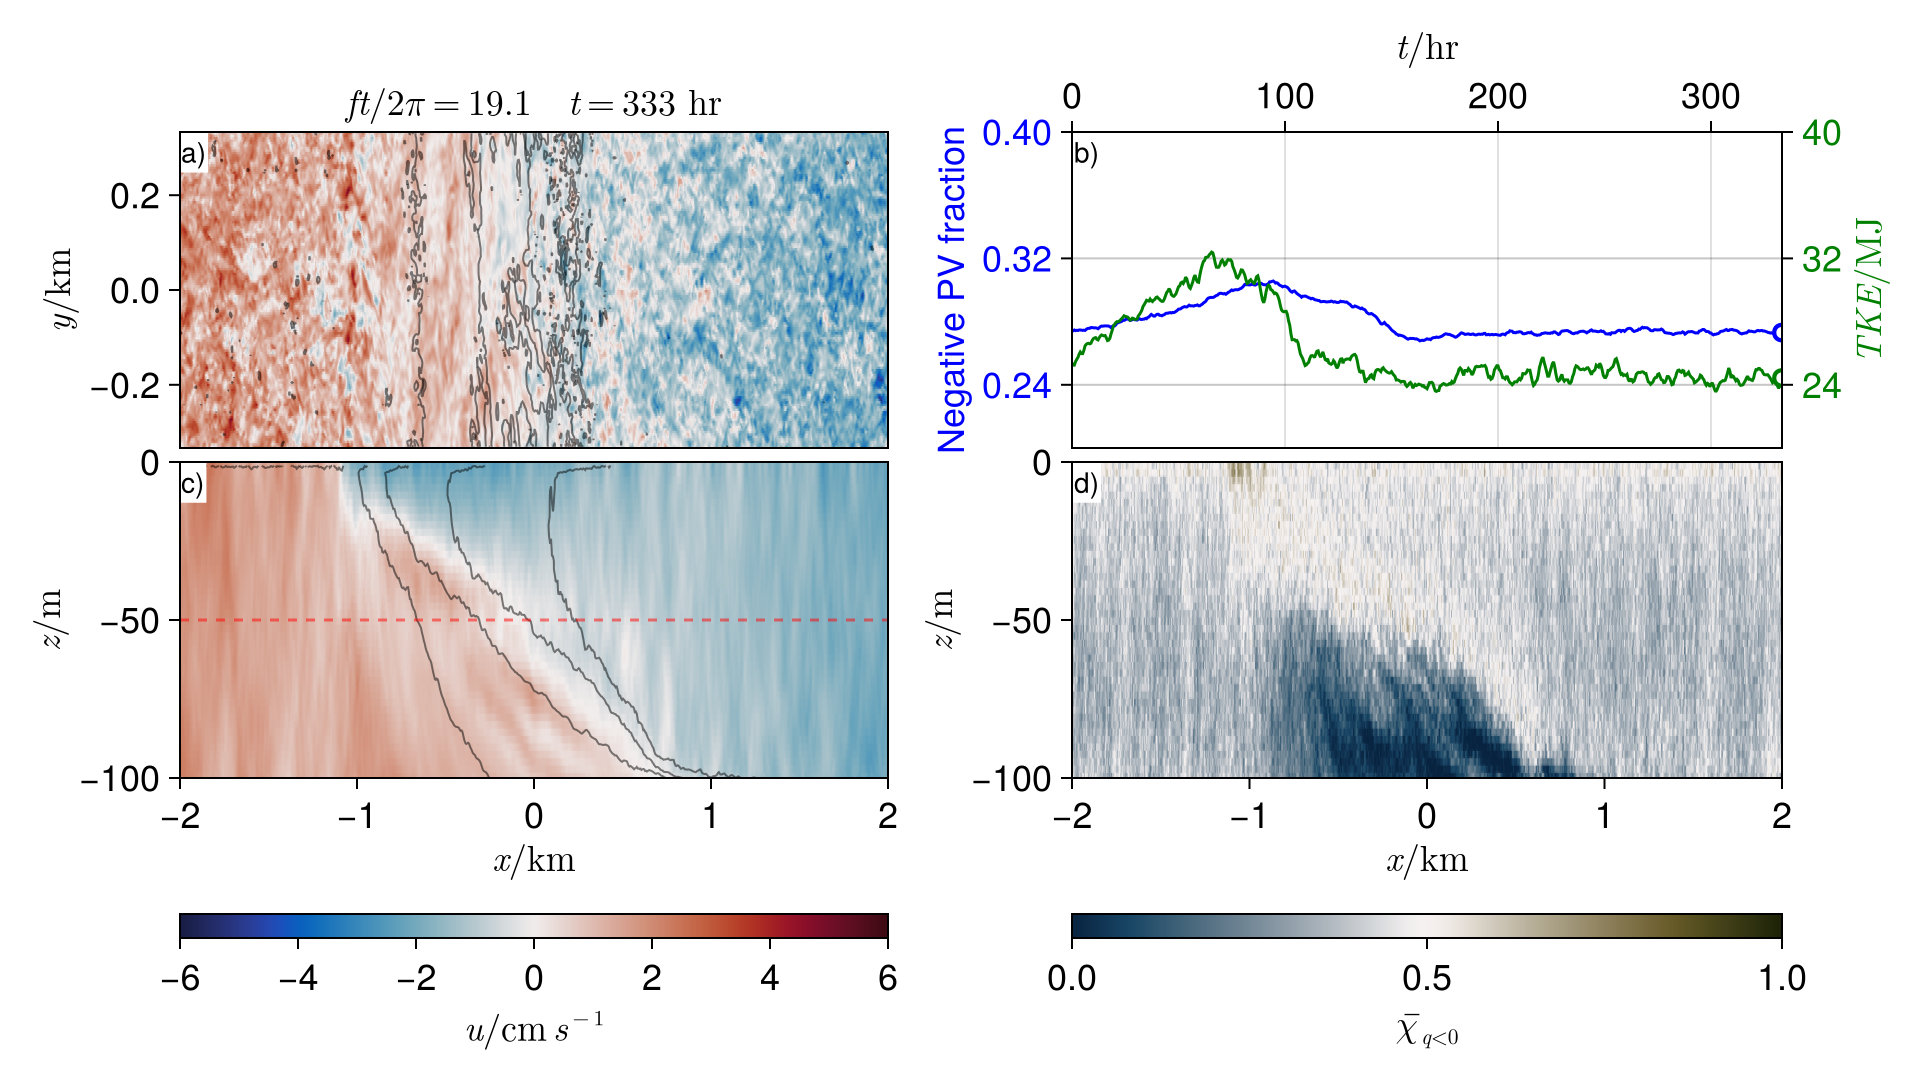

In [16]:
foldername = "../../scratch/turbulence-at-many-fronts/Strain-l8"
full_video(foldername, "full-l8.mp4", 201:801, -50; background=true, fig_kw=(; fontsize=18), record_kw=(; px_per_unit=2, framerate=12), ht_u_kw=(; highclip=nothing, lowclip=nothing))


In [ ]:
function buoyancy_video(DFM, filename)
    n = Observable(201)
    fig = Figure(; size=(1500, 300), fontsize=18)
    
    ∫αdt = normalized_time(DFM)
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    
    title = @lift let
        t_val = @sprintf "%03.1f" sp.f * times[$n] / 2π
        hr_val = @sprintf "%03.0f" times[$n] / 3600
        s_val = @sprintf "%03.2f" ∫αdt[$n]
        L"ft / 2\pi = %$(t_val) \quad s = %$(s_val) \quad t = %$(hr_val)~\text{hr} "
    end
    
    ax_x = Axis(fig[1, 1];
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lx / 2000, sp.Lx / 2000, -sp.Lz, 0),
        title
    )
    
    ax_h = Axis(fig[1, 2];
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lh / 2000, sp.Lh / 2000, -sp.Lz, 0),
        title
    )
    hideydecorations!(ax_h; ticks=false)
    
    b = @lift (get_field(DFM, "b_dfm", iterations[$n]) .- mean(b_center[$n, :])) ./ sp.Δb
    mld = @lift η[$n, :]
    
    levels = (-0.5):(1 / 6):(0.5)
    colormap = reverse(to_colormap(:deep))
    
    bl = -1 / 3
    br = 1 / 3
    ctfs = map([ax_x, ax_h]) do ax
        ctf = contourf!(ax, xsᶜ ./ 1000, zsᶜ, b; 
            colormap,
            levels,
            extendlow=:white
        )
        contour!(ax, xsᶜ ./ 1000, zsᶜ, b; 
            color = :red,
            levels = [bl]
        )
        contour!(ax, xsᶜ ./ 1000, zsᶜ, b; 
            color = :red,
            levels = [br]
        )
    
        lines!(ax, xsᶜ ./ 1000, mld;
            color = :blue
        )
    
        lines!(ax, xsᶜ ./ 1000, x->-0.05sp.H;
            color = (:black, 0.3)
        )
        lines!(ax, xsᶜ ./ 1000, x->-0.95sp.H;
            color = (:black, 0.3)
        )
        ctf
    end
    
    subfig_label!(fig[1, 1], 1; fontsize=18)
    subfig_label!(fig[1, 2], 2; fontsize=18)
    Colorbar(fig[1, 3], ctfs[1]; label=L"b / \Delta b")
    N = length(iterations)
    
    println()
    record(fig, filename, 1:N; framerate=12) do i
        print("\r$i / $N")
        n[] = i
    end
    println()
    
    fig
end

In [ ]:
buoyancy_video("../../scratch/turbulence-at-many-fronts/Strain-l2/DFM.jld2", "buoyancy-l2.mp4")
buoyancy_video("../../scratch/turbulence-at-many-fronts/Strain-l4/DFM.jld2", "buoyancy-l4.mp4")
buoyancy_video("../../scratch/turbulence-at-many-fronts/Strain-l6/DFM.jld2", "buoyancy-l6.mp4")
buoyancy_video("../../scratch/turbulence-at-many-fronts/Strain-l8/DFM.jld2", "buoyancy-l6.mp4")